 ## Sales Analysis Dashboard
This project is about 5,000 individual sales transaction record data used for business intelligence techniques. Each row represents one order, with 14 fields covering geography, product category, sales logistics, and financials.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df=pd.read_csv(r"C:\Users\sreek\Downloads\5000 Sales Records.csv")
df

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Central America and the Caribbean,Antigua and Barbuda,Baby Food,Online,M,12/20/2013,957081544,1/11/2014,552,255.28,159.42,140914.56,87999.84,52914.72
1,Central America and the Caribbean,Panama,Snacks,Offline,C,7/5/2010,301644504,7/26/2010,2167,152.58,97.44,330640.86,211152.48,119488.38
2,Europe,Czech Republic,Beverages,Offline,C,9/12/2011,478051030,9/29/2011,4778,47.45,31.79,226716.10,151892.62,74823.48
3,Asia,North Korea,Cereal,Offline,L,5/13/2010,892599952,6/15/2010,9016,205.70,117.11,1854591.20,1055863.76,798727.44
4,Asia,Sri Lanka,Snacks,Offline,C,7/20/2015,571902596,7/27/2015,7542,152.58,97.44,1150758.36,734892.48,415865.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Australia and Oceania,New Zealand,Household,Offline,C,4/3/2015,217984473,4/20/2015,5305,668.27,502.54,3545172.35,2665974.70,879197.65
4996,Middle East and North Africa,Azerbaijan,Clothes,Offline,L,8/17/2014,169748055,10/2/2014,1077,109.28,35.84,117694.56,38599.68,79094.88
4997,Asia,Myanmar,Baby Food,Offline,H,11/23/2016,226939189,12/10/2016,5204,255.28,159.42,1328477.12,829621.68,498855.44
4998,Europe,Finland,Clothes,Online,L,4/22/2014,906794202,5/11/2014,9410,109.28,35.84,1028324.80,337254.40,691070.40


### Basic info of dataset

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Region          5000 non-null   str           
 1   Country         5000 non-null   category      
 2   Item Type       5000 non-null   str           
 3   Sales Channel   5000 non-null   str           
 4   Order Priority  5000 non-null   str           
 5   Order Date      5000 non-null   datetime64[us]
 6   Order ID        5000 non-null   int64         
 7   Ship Date       5000 non-null   datetime64[us]
 8   Units Sold      5000 non-null   int64         
 9   Unit Price      5000 non-null   float64       
 10  Unit Cost       5000 non-null   float64       
 11  Total Revenue   5000 non-null   float64       
 12  Total Cost      5000 non-null   float64       
 13  Total Profit    5000 non-null   float64       
dtypes: category(1), datetime64[us](2), float64(5), int64(2), str(4)
mem

In [24]:
df.dtypes

Region                          str
Country                    category
Item Type                  category
Sales Channel                   str
Order Priority                  str
Order Date           datetime64[us]
Order ID                      int64
Ship Date            datetime64[us]
Units Sold                    int64
Unit Price                  float64
Unit Cost                   float64
Total Revenue               float64
Total Cost                  float64
Total Profit                float64
Net Profit Margin           float64
dtype: object

In [6]:
df.columns

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'],
      dtype='str')

In [7]:
df.shape

(5000, 14)

In [10]:
df.size

70000

In [8]:
df.head

<bound method NDFrame.head of                                  Region               Country   Item Type  \
0     Central America and the Caribbean  Antigua and Barbuda    Baby Food   
1     Central America and the Caribbean                Panama      Snacks   
2                                Europe        Czech Republic   Beverages   
3                                  Asia           North Korea      Cereal   
4                                  Asia             Sri Lanka      Snacks   
...                                 ...                   ...         ...   
4995              Australia and Oceania           New Zealand   Household   
4996       Middle East and North Africa            Azerbaijan     Clothes   
4997                               Asia               Myanmar   Baby Food   
4998                             Europe               Finland     Clothes   
4999                 Sub-Saharan Africa              Tanzania  Vegetables   

     Sales Channel Order Priority  Order Date

### Checking for missing values

In [9]:
df.isnull().sum()

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

### Checking the total number of duplicate rows

In [18]:
print(df["Order ID"].duplicated().sum())

0


### Changing datatype

In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Country"] = df["Country"].astype("category")
df["Item Type"] = df["Item Type"].astype("category")

### Numpy calculations

In [29]:
print("Mean:", np.mean(df["Total Revenue"]))
print("Median:", np.median(df["Total Revenue"]))
print("Std Dev:", np.std(df["Total Revenue"]))
print("Min:", np.min(df["Total Revenue"]))
print("Max:", np.max(df["Total Revenue"]))
print("Sum:", np.sum(df["Total Revenue"]))

Mean: 1325737.841708
Median: 779409.465
Std Dev: 1475227.1285153339
Min: 65.31
Max: 6672675.95
Sum: 6628689208.54


### Basic calculations

In [21]:
df["Net Profit Margin"] = (df["Total Profit"] / df["Total Revenue"]) * 100
df["Net Profit Margin"]

0       37.550924
1       36.138419
2       33.003161
3       43.067574
4       36.138419
          ...    
4995    24.799856
4996    67.203514
4997    37.550924
4998    67.203514
4999    40.977541
Name: Net Profit Margin, Length: 5000, dtype: float64

In [23]:
bb=df.groupby(["Item Type", "Region"])[["Total Revenue", "Total Profit"]].sum()
bb

Total Revenue  Total Profit
Item Type  Region                                                        
Baby Food  Asia                                8.608807e+07   32326867.80
           Australia and Oceania               5.569546e+07   20914159.64
           Central America and the Caribbean   6.095116e+07   22887725.32
           Europe                              1.436476e+08   53940997.16
           Middle East and North Africa        6.967485e+07   26163549.10
...                                                     ...           ...
Vegetables Central America and the Caribbean   4.127699e+07   16914294.64
           Europe                              8.974673e+07   36776002.72
           Middle East and North Africa        3.835200e+07   15715708.46
           North America                       4.469127e+06    1831338.17
           Sub-Saharan Africa                  7.912645e+07   32424073.04

[84 rows x 2 columns]

In [26]:
dd=df.groupby("Region")[["Total Revenue", "Total Profit"]].sum()
dd

,Total Revenue,Total Profit
Region,,
Asia,9.202771e+08,2.782377e+08
Australia and Oceania,5.873641e+08,1.749346e+08
Central America and the Caribbean,6.849763e+08,2.046120e+08
Europe,1.703622e+09,5.016760e+08
Middle East and North Africa,7.668678e+08,2.313803e+08
North America,1.510143e+08,4.124040e+07
Sub-Saharan Africa,1.814567e+09,5.311423e+08


In [27]:
on_of=df.groupby("Sales Channel")[["Total Revenue", "Total Profit", "Units Sold"]].sum()
on_of

,Total Revenue,Total Profit,Units Sold
Sales Channel,,,
Offline,3.378779e+09,9.936100e+08,12569591
Online,3.249910e+09,9.696132e+08,12583900


In [28]:
top10 = df.groupby("Country")["Total Revenue"].sum().sort_values(ascending=False).head(10)
top10

Country
Rwanda                   60398739.59
Myanmar                  58838467.85
South Korea              57434355.43
Ghana                    56271382.65
Niger                    55298211.28
Grenada                  54988184.55
Republic of the Congo    54379808.39
Kosovo                   53833142.79
Czech Republic           53543932.14
Ukraine                  53252317.54
Name: Total Revenue, dtype: float64

### EDA & Visualization

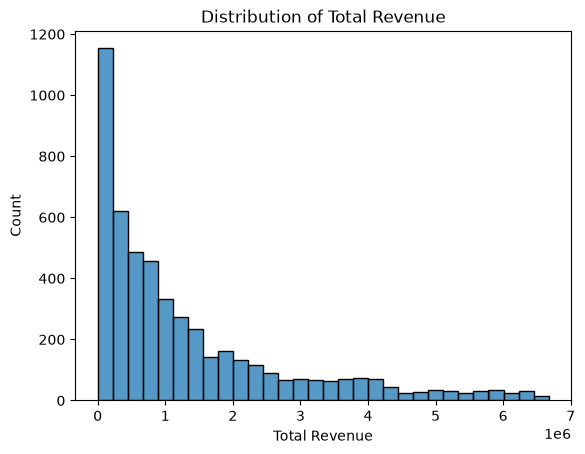

In [4]:
sns.histplot(df["Total Revenue"], bins=30)
plt.title("Distribution of Total Revenue")
plt.show()

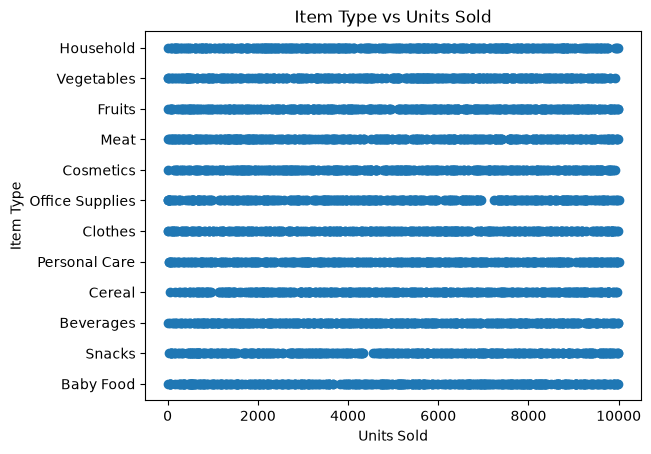

In [6]:
plt.scatter(df["Units Sold"], df["Item Type"])
plt.xlabel("Units Sold")
plt.ylabel("Item Type")
plt.title("Item Type vs Units Sold")
plt.show()

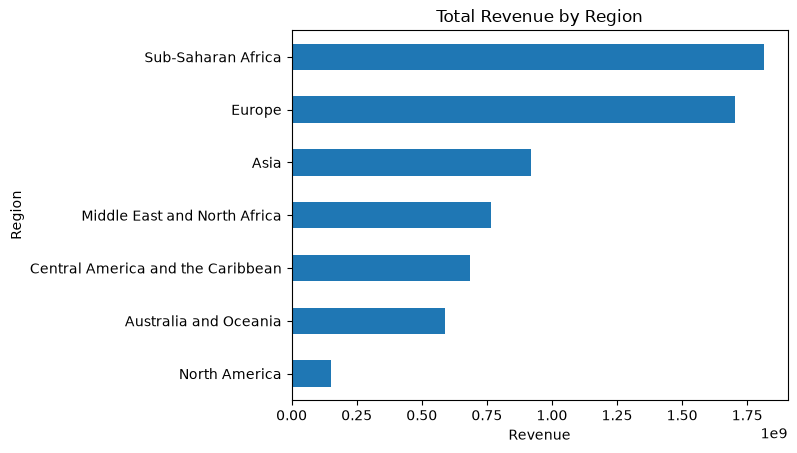

In [11]:
df.groupby("Region")["Total Revenue"].sum().sort_values().plot(kind="barh")
plt.title("Total Revenue by Region")
plt.xlabel("Revenue")
plt.show()

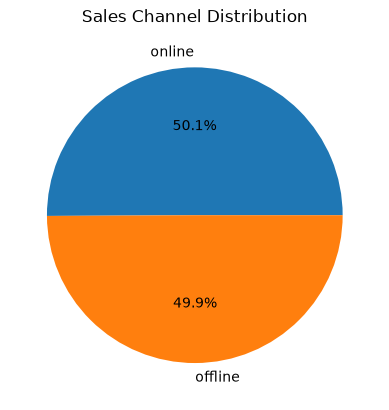

In [12]:
counts = df["Sales Channel"].value_counts()
mylabels=["online","offline"]
plt.pie(counts.values, labels=mylabels, autopct="%1.1f%%")
plt.title("Sales Channel Distribution")
plt.show()

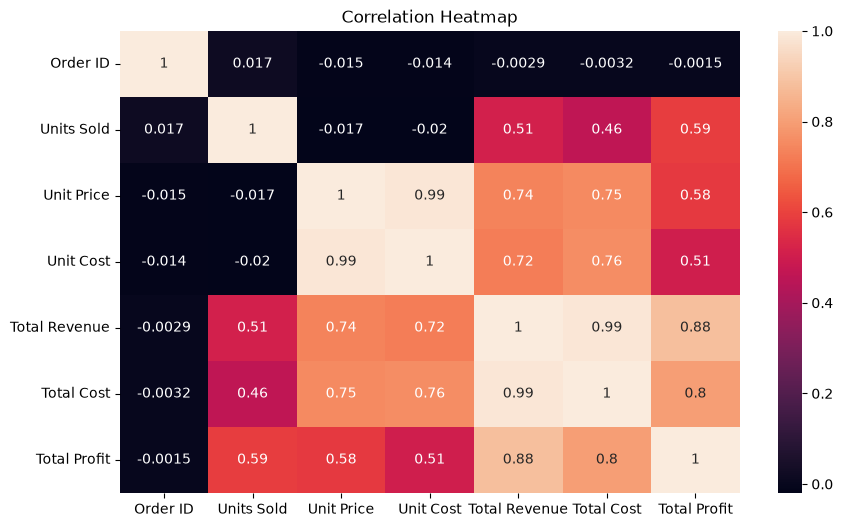

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

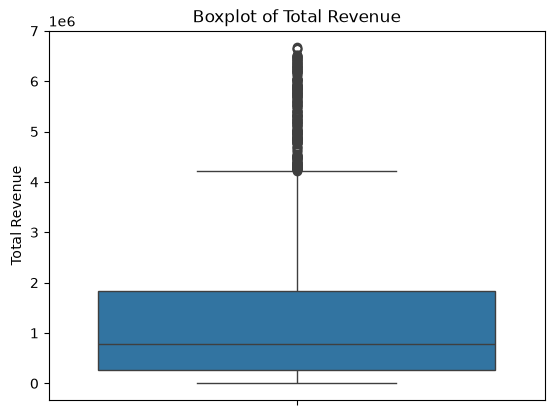

In [15]:
sns.boxplot(df["Total Revenue"])
plt.title("Boxplot of Total Revenue")
plt.show()

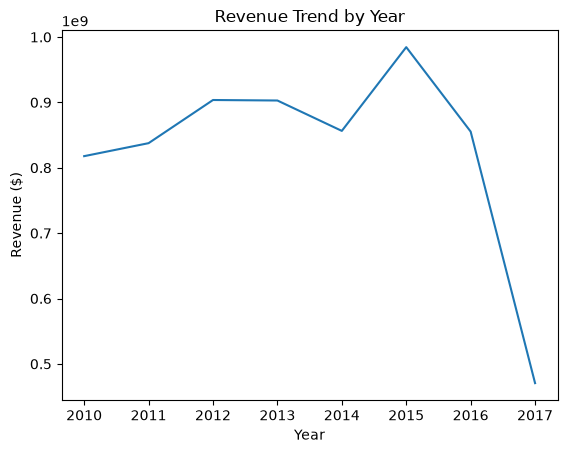

In [24]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
yearly=df.groupby(df["Order Date"].dt.year)["Total Revenue"].sum()
plt.plot(yearly.index, yearly.values)
plt.title("Revenue Trend by Year")
plt.xlabel("Year")
plt.ylabel("Revenue ($)")
plt.show()

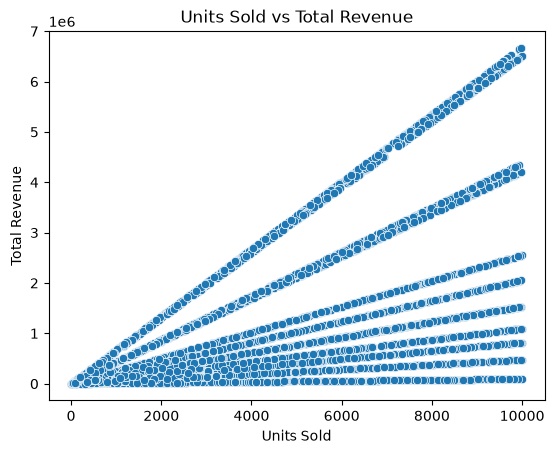

In [25]:
sns.scatterplot(x="Units Sold", y="Total Revenue", data=df)
plt.title("Units Sold vs Total Revenue")
plt.show()

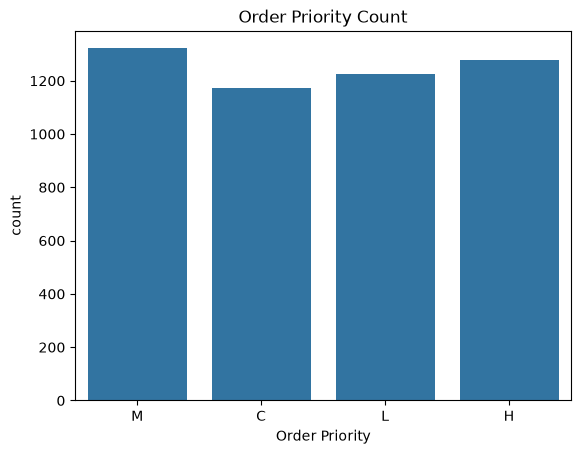

In [26]:
sns.countplot(x="Order Priority", data=df)
plt.title("Order Priority Count")
plt.show()

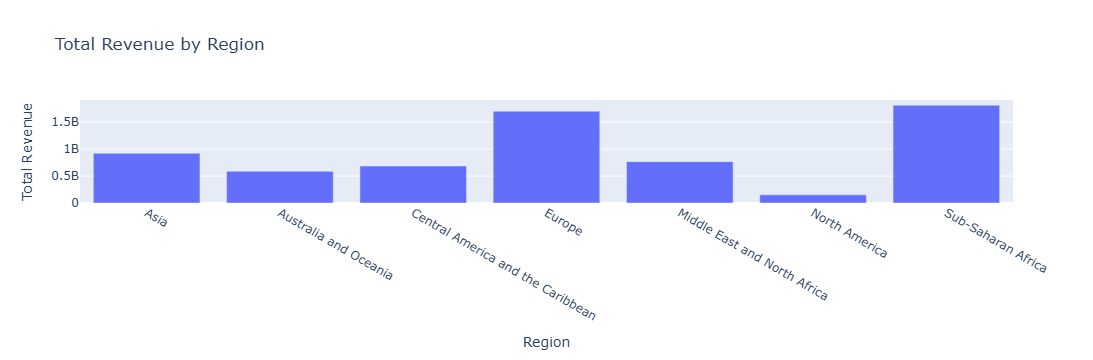

In [27]:
fig = px.bar(df.groupby("Region")["Total Revenue"].sum().reset_index(),
x="Region", y="Total Revenue",title="Total Revenue by Region")
fig.show()

## INSIGHT AND CONCLUSION

### Key Insights

#### 1. Overall Performance

1. Total Revenue:6.63 billion across
2. Total Profit:1.96 billion
3. Total Units Sold: 25.1 million

#### 2. Regional Performance
Sub-Saharan Africa and Europe are the top two revenue-generating regions 

#### 3. Sales Channel
Online and Offline channels are almost perfectly split (49% vs 51% of revenue)

#### 4. Order Priority
Medium order priority has the highest count followed by High order priority

#### 5. Time Analysis
2015 was the strongest year representing the highest point on the chart.

#### 6. Product Category Performance
1. Household and Office Supplies are the top revenue-generating categories.
2. Fruits is the most sold item type, the highest among all 12 categories.

### Conclusion
This dataset reflects a moderately profitable retail business with a healthy profit margin.The biggest lever for improving overall profitability isn't selling more units, but it's by optimizing pricing and cost per unit.